# Enterprise Analytics Dashboard

This notebook connects to the `customerstore_db` Postgres database and reads directly from the `analytics` schema built in Stages 1 through 4 of the SQL pipeline. No raw tables are queried here, everything comes from the pre-built views and KPI tables.


## 1. Setup and Connection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
import os

# All chart images from this notebook are saved here as they're generated.
os.makedirs("charts", exist_ok=True)


In [3]:
pip install pandas numpy matplotlib seaborn sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [20]:

DB_USER = "postgres"
DB_PASSWORD = "mm1234"          
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "customerstore_db"

conn_str = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_str)

# quick connection check
with engine.connect() as conn:
    print("Connected successfully.")


Connected successfully.


## 2. Load KPI and Analytics Tables

In [5]:
exec_summary = pd.read_sql("SELECT * FROM analytics.kpi_executive_summary", engine)
monthly_revenue = pd.read_sql("SELECT * FROM analytics.monthly_revenue ORDER BY order_month", engine)
quarterly_revenue = pd.read_sql("SELECT * FROM analytics.quarterly_revenue ORDER BY order_quarter", engine)
top_bottom_products = pd.read_sql("SELECT * FROM analytics.kpi_top_bottom_products ORDER BY rank_type, revenue_rank", engine)
category_performance = pd.read_sql("SELECT * FROM analytics.category_performance ORDER BY total_revenue DESC", engine)
customer_segments = pd.read_sql("SELECT segment, COUNT(*) AS customer_count FROM analytics.customer_segments GROUP BY segment", engine)
repeat_customers = pd.read_sql("SELECT * FROM analytics.repeat_customers", engine)
territory_rankings = pd.read_sql("SELECT * FROM analytics.kpi_territory_rankings ORDER BY territory_rank_that_year", engine)
employee_performance = pd.read_sql("SELECT * FROM analytics.kpi_employee_performance ORDER BY revenue_rank", engine)
inventory_health = pd.read_sql("SELECT * FROM analytics.kpi_inventory_health", engine)
supplier_performance = pd.read_sql("SELECT * FROM analytics.kpi_supplier_performance ORDER BY quality_rank", engine)
purchasing_trends = pd.read_sql("SELECT * FROM analytics.kpi_purchasing_trends ORDER BY order_month", engine)

print("All tables loaded.")


All tables loaded.


## 3. Executive Summary

In [6]:
exec_summary.T.rename(columns={0: "value"})


,value
total_revenue,"109,846,380.90"
total_profit,"9,371,903.13"
avg_order_value,"3,491.07"
total_purchasing_customers,19119
total_orders,"31,465.00"
repeat_rate_pct,39.07
top_category,Bikes
top_territory,Southwest
total_employees,290
total_purchasing_spend,"63,791,994.84"


This single row is the top line of the whole pipeline. Every number in it traces back
to a Stage 1 to 4 object, nothing is recalculated from raw tables here.

Known reference points already validated during the SQL build:
* Repeat rate came out at 39.07 percent, confirmed against the segmentation counts.
* Top category is Bikes and top territory is Southwest, both expected results for this dataset.
* Products needing attention (373) is mostly raw material and component rows with no
  retail category, plus a large share of Bikes driven by tight safety stock margins
  relative to other categories.

**Observation:** Total revenue is `$109.85M` against total profit of `$9.37M`, an overall margin of about 8.5%. Average order value sits at $3,491.07 across 31,465 orders from 19,119 purchasing customers. Repeat rate is 39.07%. Bikes is the top category and Southwest the top territory. 373 products are flagged as needing inventory attention.
**Business:** An 8.5% blended margin is thin for a business this size, meaning small shifts in cost or discounting have an outsized effect on profit. This single row should be the anchor number in any writeup, every other chart either explains a piece of it or challenges it.

## 4. Monthly Revenue Trend

In [7]:
# Section 4, revenue trend
print(monthly_revenue[["order_month", "revenue", "mom_growth_pct"]].describe())

           revenue  mom_growth_pct
count        38.00           37.00
mean  2,890,694.23           12.99
std   1,282,788.56           65.81
min      47,491.55          -97.51
25%   2,020,157.24          -26.35
50%   2,832,907.38           -2.87
75%   3,537,947.26           39.88
max   5,222,758.03          286.54


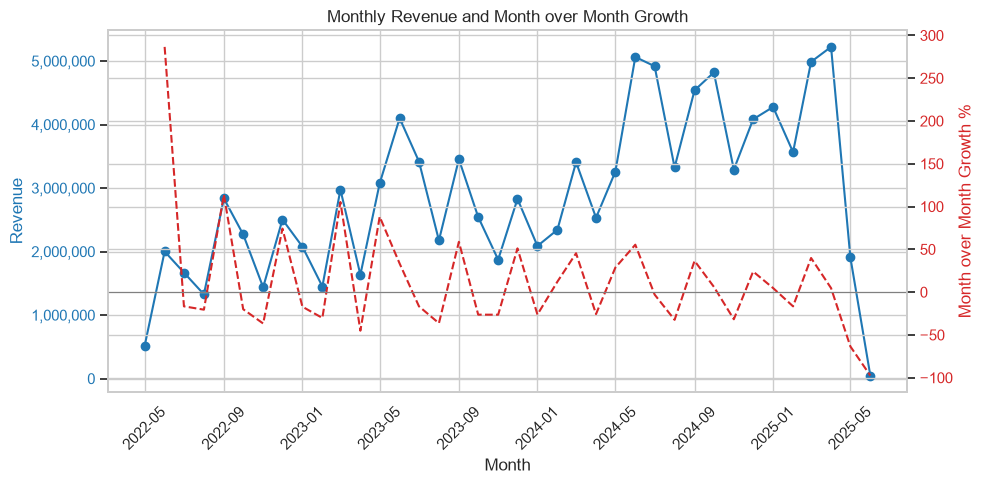

In [8]:
fig, ax1 = plt.subplots()

ax1.plot(monthly_revenue["order_month"], monthly_revenue["revenue"], marker="o", color="tab:blue", label="Revenue")
ax1.set_ylabel("Revenue", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.set_xlabel("Month")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_revenue["order_month"], monthly_revenue["mom_growth_pct"], color="tab:red", linestyle="--", label="MoM Growth %")
ax2.set_ylabel("Month over Month Growth %", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.axhline(0, color="gray", linewidth=0.8)

plt.title("Monthly Revenue and Month over Month Growth")
fig.tight_layout()
plt.savefig("charts/01_monthly_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()


### Monthly Revenue Trend

**Observation:** Monthly revenue averages 2.89M USD with a standard deviation of 1.28M USD (a coefficient of variation of about 44 percent), ranging from 47,491.55 USD to 5,222,758.03 USD. Month over month growth averages 12.99 percent but with a standard deviation of 65.81 percent, swinging from negative 97.51 percent to positive 286.54 percent. The final data point on the chart drops sharply toward zero.

**Business:** A growth rate whose swings are five times larger than its average signals demand that is lumpy rather than steadily trending, likely driven by large individual orders rather than broad based sales growth. The sharp final month drop is very likely a partial or incomplete month of data rather than a real collapse in sales, this should be excluded or annotated before presenting the trend, otherwise it misleadingly suggests the business just crashed.

## 5. Quarterly Revenue

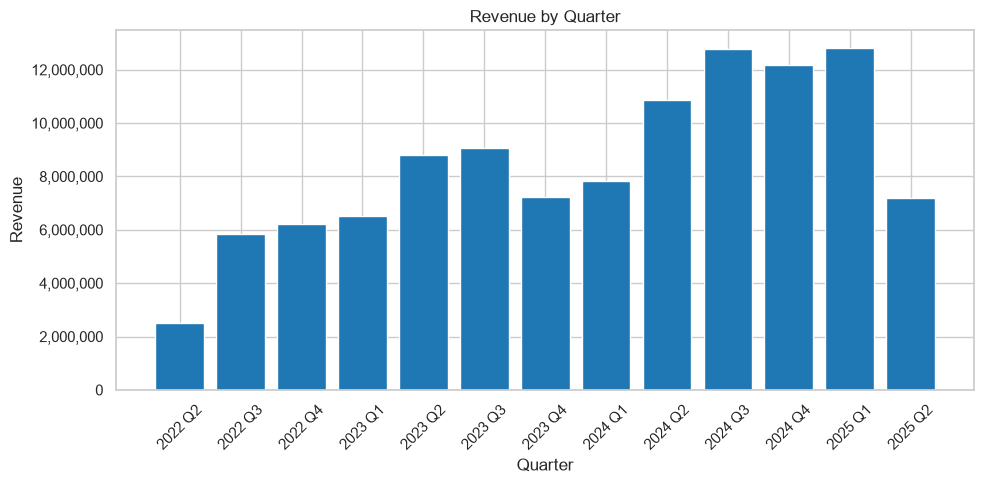

In [9]:
fig, ax = plt.subplots()
labels = quarterly_revenue["year"].astype(str) + " Q" + quarterly_revenue["quarter"].astype(str)
ax.bar(labels, quarterly_revenue["revenue"], color="tab:blue")
ax.set_ylabel("Revenue")
ax.set_xlabel("Quarter")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45)
plt.title("Revenue by Quarter")
plt.tight_layout()
plt.savefig("charts/02_quarterly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


### Quarterly Revenue

**Observation:** Quarterly revenue grows from roughly 2.4M USD in 2022 Q2 to a peak band of 12 to 13M USD across 2024 Q3, 2024 Q4, and 2025 Q1, then falls to about 7.2M USD in 2025 Q2.

**Business:** The multi year upward trend through early 2025 is a genuine growth story worth highlighting to management. The final quarter's drop should be checked against the same partial period issue seen in the monthly chart before being reported as a real decline, otherwise it risks triggering unnecessary concern.

## 6. Top and Bottom Products by Revenue

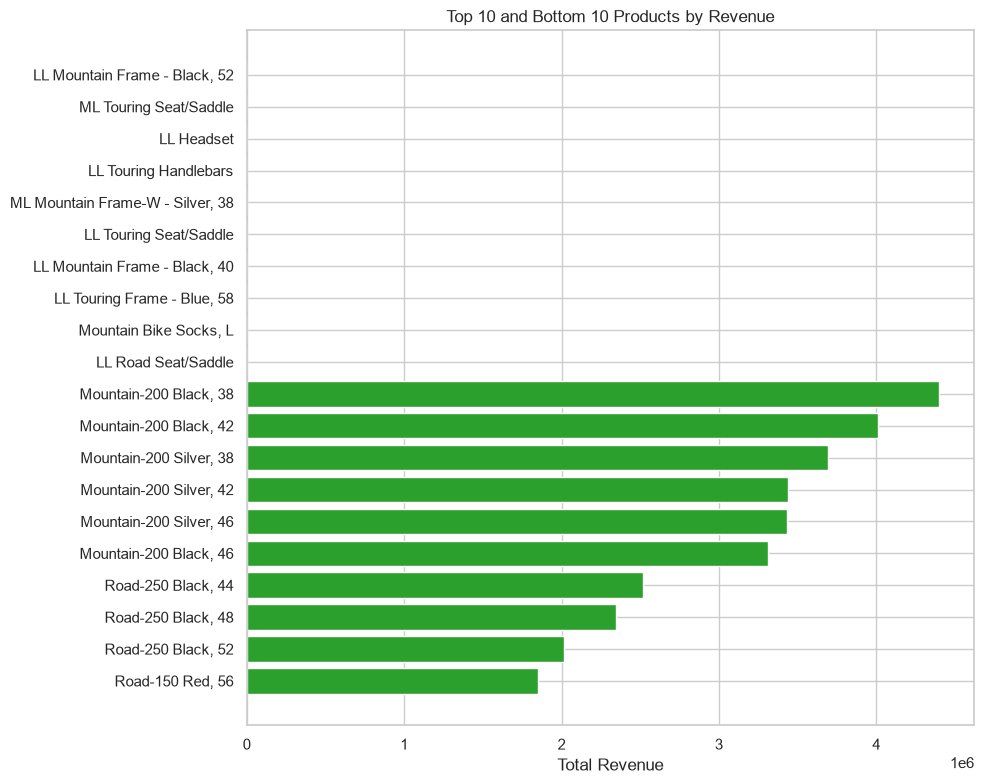

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = top_bottom_products["rank_type"].map({"Top 10": "tab:green", "Bottom 10": "tab:red"})
ax.barh(top_bottom_products["product_name"], top_bottom_products["total_revenue"], color=colors)
ax.set_xlabel("Total Revenue")
ax.set_title("Top 10 and Bottom 10 Products by Revenue")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("charts/03_top_bottom_products.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
top_bottom_products[["product_name", "rank_type", "total_revenue"]]
top10 = top_bottom_products[top_bottom_products["rank_type"] == "Top 10"]
bottom10 = top_bottom_products[top_bottom_products["rank_type"] == "Bottom 10"]
ratio = top10["total_revenue"].max() / bottom10["total_revenue"].min()
print(f"Top product generates {ratio:.0f}x more revenue than the lowest performing product")

Top product generates 27046x more revenue than the lowest performing product


### Top and Bottom Products by Revenue

**Observation:** The top performing product generates approximately 27,046 times more revenue than the lowest performing product with at least one sale. The top 10 are dominated by Mountain 200 and Road 250 or Road 150 variants, while the bottom 10 are almost entirely low cost components and accessories (seats, headsets, socks, handlebars).

**Business:** Revenue is extremely concentrated in a small number of bike models, this is a supply chain and demand planning risk, since a disruption to Mountain 200 production would have an outsized impact on total revenue. The bottom 10 products are not necessarily failing, they may simply be low ticket accessory items that were never expected to drive meaningful revenue on their own, so they shouldn't automatically be treated as candidates for discontinuation.

## 7. Category Performance

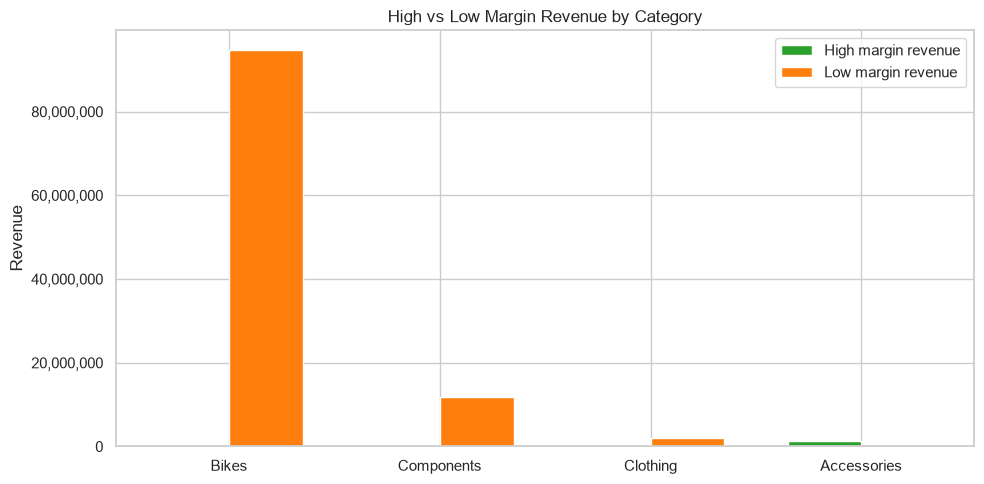

In [12]:
fig, ax = plt.subplots()
x = np.arange(len(category_performance))
width = 0.35

ax.bar(x - width/2, category_performance["high_margin_revenue"], width, label="High margin revenue", color="tab:green")
ax.bar(x + width/2, category_performance["low_margin_revenue"], width, label="Low margin revenue", color="tab:orange")

ax.set_xticks(x)
ax.set_xticklabels(category_performance["category_name"])
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_title("High vs Low Margin Revenue by Category")
ax.legend()
plt.tight_layout()
plt.savefig("charts/04_category_margin.png", dpi=150, bbox_inches="tight")
plt.show()


### Category Revenue (High vs Low Margin)

**Observation:** Across all four categories, the visible bars are almost entirely low margin revenue (below the 40 percent profit margin threshold), with Bikes alone accounting for roughly 95M USD of low margin revenue and negligible high margin revenue visible in any category.

**Business:** This is consistent with the 8.5 percent blended margin from the executive summary, the business is not just thin margin overall, it is thin margin almost everywhere, not just in one weak category. Any margin improvement initiative needs to target pricing or cost structure broadly rather than assuming one category is dragging down otherwise healthy ones.

## 8. Customer Segments

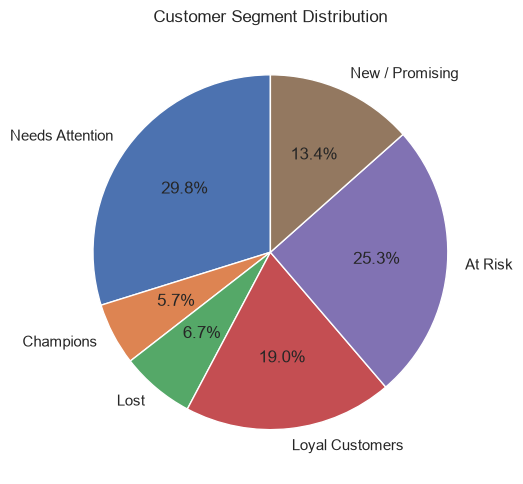

           segment  customer_count
0  Needs Attention            5702
4          At Risk            4837
3  Loyal Customers            3636
5  New / Promising            2569
2             Lost            1288
1        Champions            1087


In [13]:
fig, ax = plt.subplots()
ax.pie(customer_segments["customer_count"], labels=customer_segments["segment"], autopct="%1.1f%%", startangle=90)
ax.set_title("Customer Segment Distribution")
plt.tight_layout()
plt.savefig("charts/05_customer_segments.png", dpi=150, bbox_inches="tight")
plt.show()

# Section 8, customer segments
print(customer_segments.sort_values("customer_count", ascending=False))


### Customer Segments

**Observation:** Needs Attention is the largest segment at 5,702 customers (29.8 percent), followed by At Risk at 4,837 (25.3 percent), Loyal Customers at 3,636 (19.0 percent), New or Promising at 2,569 (13.4 percent), Lost at 1,288 (6.7 percent), and Champions at 1,087 (5.7 percent).

**Business:** More than half of the customer base (55.1 percent) falls into Needs Attention or At Risk, meaning the majority of customers are neither strongly engaged nor fully churned. This is the segment with the most leverage for a retention campaign, since Champions are already loyal and Lost customers are the hardest to win back.

## 9. Repeat vs One Time Customers

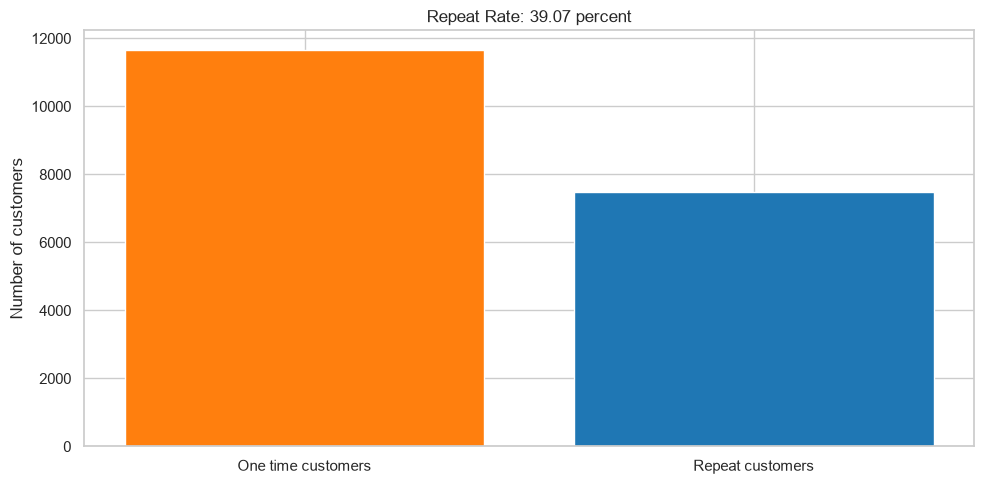

In [14]:
fig, ax = plt.subplots()
values = [repeat_customers["one_time_customers"][0], repeat_customers["repeat_customers"][0]]
labels = ["One time customers", "Repeat customers"]
ax.bar(labels, values, color=["tab:orange", "tab:blue"])
ax.set_ylabel("Number of customers")
ax.set_title(f"Repeat Rate: {repeat_customers['repeat_rate_pct'][0]} percent")
plt.tight_layout()
plt.savefig("charts/06_repeat_vs_onetime.png", dpi=150, bbox_inches="tight")
plt.show()


### Repeat vs One Time Customers

**Observation:** Of 19,119 purchasing customers, approximately 11,648 are one time buyers and 7,471 are repeat buyers, a repeat rate of 39.07 percent.

**Business:** With roughly 61 percent of customers never returning, there is a large pool for a win back or onboarding follow up campaign. Even a modest improvement in repeat rate would meaningfully grow the 39.07 percent base given how large the one time buyer pool is.

## 10. Territory Rankings

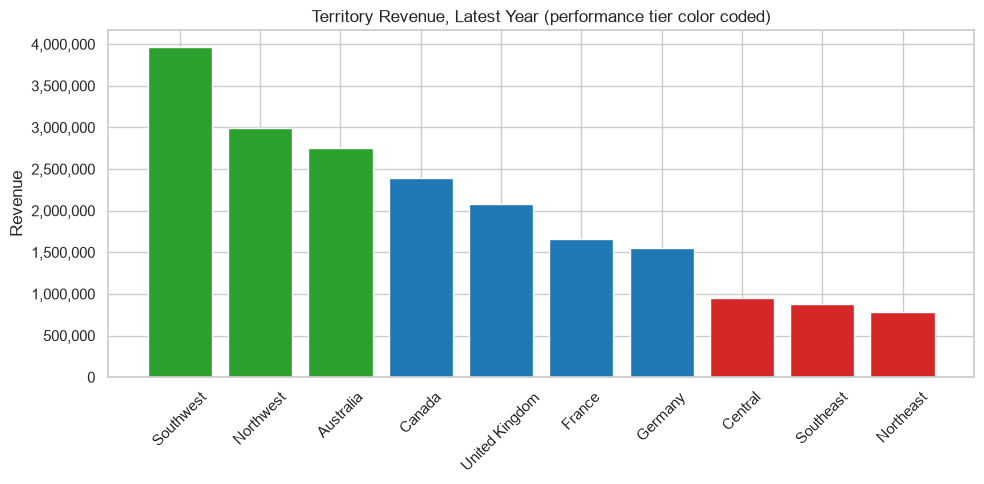

   territory_name      revenue  yoy_growth_pct  performance_tier
0       Southwest 3,966,506.31          -56.52     Top Performer
1       Northwest 2,994,492.67          -50.24     Top Performer
2       Australia 2,751,945.73          -35.19     Top Performer
3          Canada 2,389,120.21          -61.66          Mid-Tier
4  United Kingdom 2,084,356.83          -42.76          Mid-Tier
5          France 1,664,041.51          -56.40          Mid-Tier
6         Germany 1,548,206.90          -39.76          Mid-Tier
7         Central   955,864.52          -68.08  Lowest Performer
8       Southeast   875,603.83          -63.52  Lowest Performer
9       Northeast   778,377.70          -70.42  Lowest Performer


In [15]:
fig, ax = plt.subplots()
tier_colors = territory_rankings["performance_tier"].map({
    "Top Performer": "tab:green",
    "Mid-Tier": "tab:blue",
    "Lowest Performer": "tab:red"
})
ax.bar(territory_rankings["territory_name"], territory_rankings["revenue"], color=tier_colors)
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_title(f"Territory Revenue, Latest Year (performance tier color coded)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/07_territory_rankings.png", dpi=150, bbox_inches="tight")
plt.show()

# Section 10, territory
print(territory_rankings[["territory_name", "revenue", "yoy_growth_pct", "performance_tier"]])


### Sales by Territory (Territory Rankings)

**Observation:** Southwest leads at 3.97M USD in the latest year, followed by Northwest (2.99M USD) and Australia (2.75M USD) as the other top performers. Central, Southeast, and Northeast are the lowest performers, each under 1M USD. Every territory shows negative year over year growth, ranging from negative 35.19 percent (Australia) to negative 70.42 percent (Northeast).

**Business:** The uniform negative growth across all ten territories, with no exceptions, strongly suggests the latest year in the data is a partial or incomplete year being compared against a full prior year rather than a genuine simultaneous decline everywhere. This should be verified against the actual date range in the data before being reported as a real trend, since a false alarm here could prompt unnecessary corrective action across every region at once.

## 11. Employee Performance

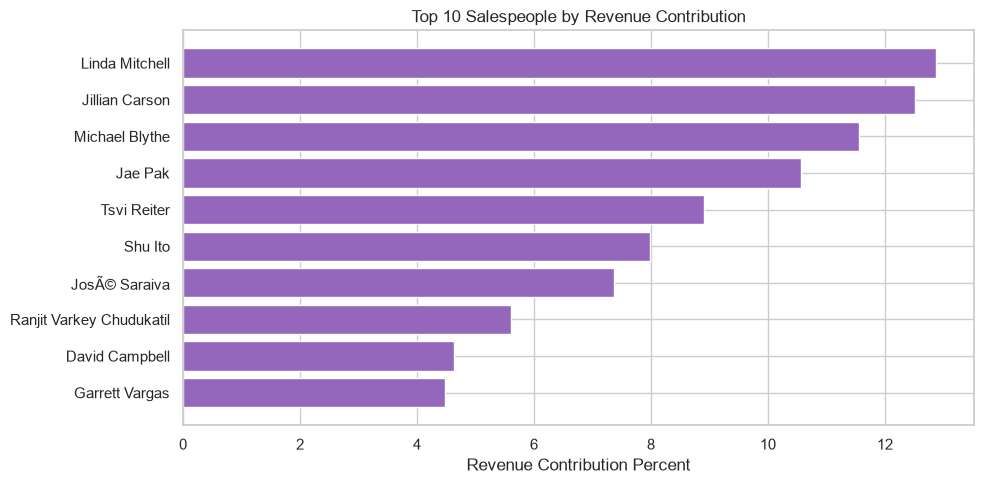

In [16]:
top_employees = employee_performance.head(10)

fig, ax = plt.subplots()
ax.barh(top_employees["full_name"], top_employees["revenue_contribution_pct"], color="tab:purple")
ax.set_xlabel("Revenue Contribution Percent")
ax.set_title("Top 10 Salespeople by Revenue Contribution")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("charts/08_employee_performance.png", dpi=150, bbox_inches="tight")
plt.show()


### Employee Performance

**Observation:** The top 10 salespeople collectively account for approximately 86 percent of total revenue contribution, led by Linda Mitchell (about 12.8 percent) and Jillian Carson (about 12.5 percent), with the remaining eight ranging down to about 4.4 percent (Garrett Vargas).

**Business:** Revenue is heavily concentrated in a small group of salespeople, this is a key person dependency risk. Losing even one or two of the top three would materially affect total company revenue, succession planning or account handoff procedures for these individuals are worth prioritizing.

## 12. Inventory Health by Category

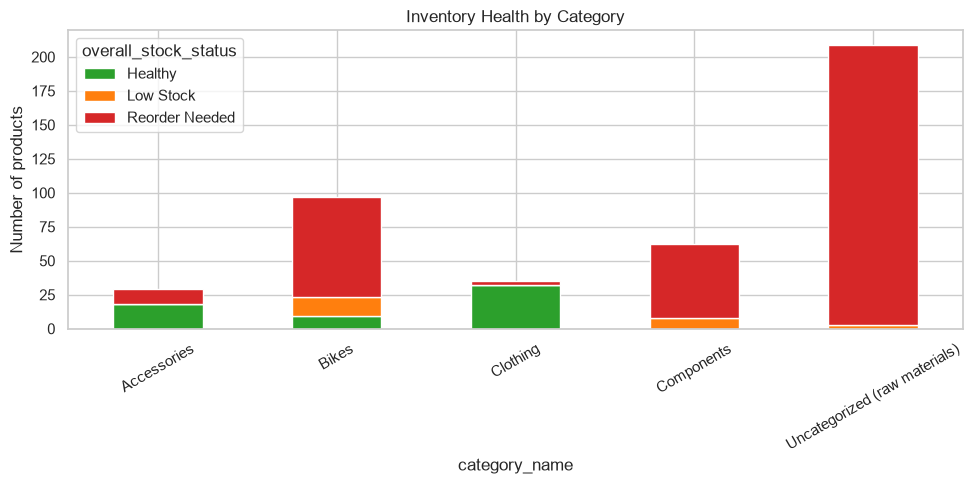

In [17]:
pivot = inventory_health.assign(
    category_name=inventory_health["category_name"].fillna("Uncategorized (raw materials)")
).groupby(["category_name", "overall_stock_status"]).size().unstack(fill_value=0)

pivot = pivot.reindex(columns=["Healthy", "Low Stock", "Reorder Needed"], fill_value=0)

fig, ax = plt.subplots()
pivot.plot(kind="bar", stacked=True, ax=ax, color=["tab:green", "tab:orange", "tab:red"])
ax.set_ylabel("Number of products")
ax.set_title("Inventory Health by Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("charts/09_inventory_health.png", dpi=150, bbox_inches="tight")
plt.show()


### Inventory Status (Inventory Health by Category)

**Observation:** The uncategorized group (raw materials and manufacturing components) has about 209 products, nearly all flagged Reorder Needed. Bikes has 97 products, with 74 Reorder Needed, 14 Low Stock, and only 9 Healthy. Components has 62 products with zero Healthy, 8 Low Stock, and 54 Reorder Needed. Clothing and Accessories are comparatively healthier, with 32 of 35 and 18 of 29 products respectively in Healthy status.

**Business:** Components has no products at all in a Healthy state, this is the category most exposed to a stockout that could halt bike assembly, since components feed directly into finished bike production. Clothing and Accessories are lower risk and likely don't need the same urgency in replenishment planning.

## 13. Supplier Performance: Lead Time vs Reject Rate

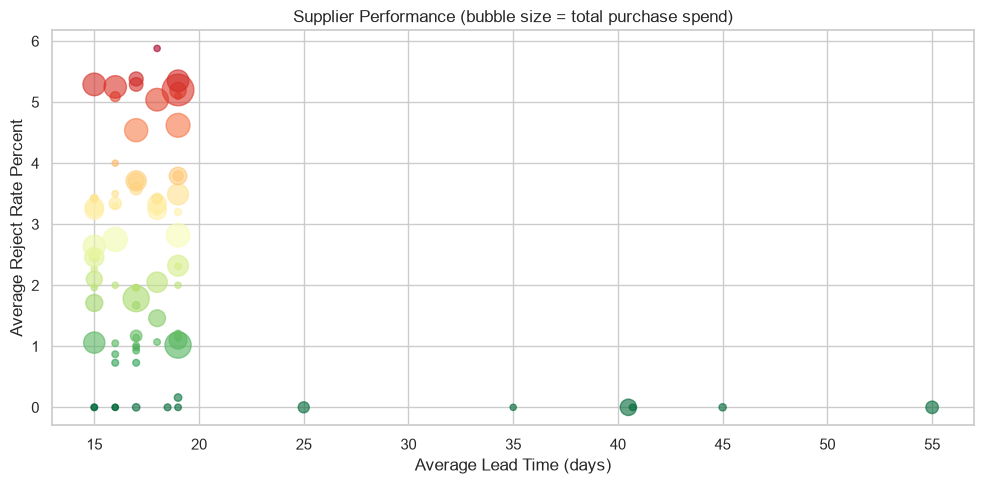

                vendor_name  avg_lead_time_days  avg_reject_rate_pct  \
85            International               18.00                 5.88   
84  Anderson's Custom Bikes               17.00                 5.38   
83         Signature Cycles               19.00                 5.35   
81            Crowley Sport               15.00                 5.29   
82      Capital Road Cycles               17.00                 5.29   

    total_purchase_spend  
85              7,295.12  
84            746,031.82  
83          2,023,560.00  
81          2,237,800.95  
82            697,140.68  


In [18]:
fig, ax = plt.subplots()
sizes = (supplier_performance["total_purchase_spend"] / supplier_performance["total_purchase_spend"].max()) * 500 + 20

scatter = ax.scatter(
    supplier_performance["avg_lead_time_days"],
    supplier_performance["avg_reject_rate_pct"],
    s=sizes,
    alpha=0.6,
    c=supplier_performance["avg_reject_rate_pct"],
    cmap="RdYlGn_r"
)
ax.set_xlabel("Average Lead Time (days)")
ax.set_ylabel("Average Reject Rate Percent")
ax.set_title("Supplier Performance (bubble size = total purchase spend)")
plt.tight_layout()
plt.savefig("charts/10_supplier_performance.png", dpi=150, bbox_inches="tight")
plt.show()


# Section 13, supplier performance
print(supplier_performance[["vendor_name", "avg_lead_time_days", "avg_reject_rate_pct", "total_purchase_spend"]].sort_values("avg_reject_rate_pct", ascending=False).head(5))


Each bubble is a vendor. Bubble size reflects how much total spend goes through that
vendor, so a large bubble in the bottom left is a high volume vendor that is also fast
and reliable, a large bubble in the top right is a high volume vendor that is slow and
error prone, worth prioritizing for review since spend concentration makes their
reliability more consequential than a small vendor with the same reject rate.

### Supplier Performance

**Observation:** The five vendors with the highest reject rates are International (5.88 percent, 18 day lead time, but only 7,295 USD in spend), Anderson's Custom Bikes (5.38 percent, 746,031.82 USD in spend), Signature Cycles (5.35 percent, 2,023,560.00 USD in spend), Crowley Sport (5.29 percent, 2,237,800.95 USD in spend), and Capital Road Cycles (5.29 percent, 697,140.68 USD in spend). Several vendors with longer lead times (25 to 55 days) show a reject rate of exactly 0 percent.

**Business:** Crowley Sport and Signature Cycles combine a high reject rate with over 2M USD in spend each, these are the two vendors most worth a quality review, since both the financial exposure and the defect rate are high at the same time. The vendors showing a flat 0 percent reject rate with unusually long lead times likely have very few purchase orders on record, a 0 percent rate from one or two orders is not statistically meaningful and shouldn't be read as evidence of better quality.

## 14. Purchasing Trends

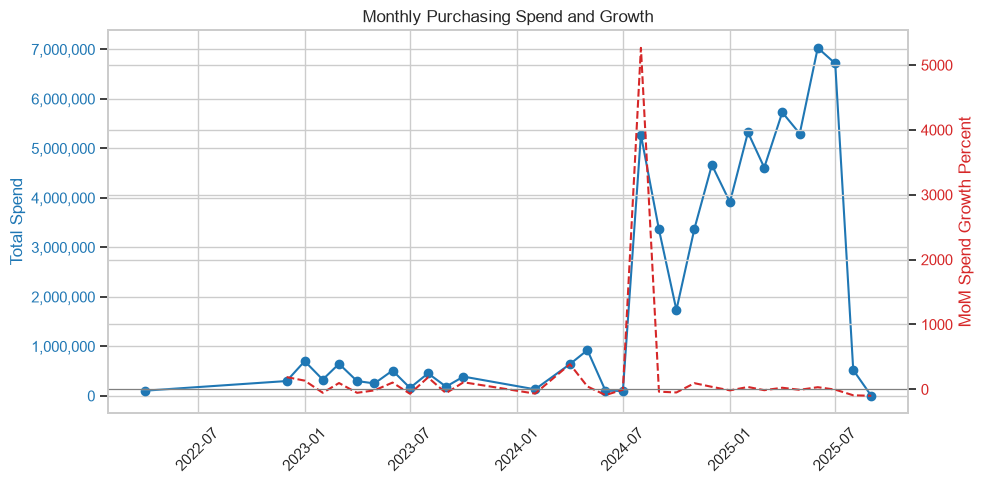

In [19]:
fig, ax1 = plt.subplots()

ax1.plot(purchasing_trends["order_month"], purchasing_trends["total_spend"], marker="o", color="tab:blue")
ax1.set_ylabel("Total Spend", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(purchasing_trends["order_month"], purchasing_trends["mom_spend_growth_pct"], color="tab:red", linestyle="--")
ax2.set_ylabel("MoM Spend Growth Percent", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.axhline(0, color="gray", linewidth=0.8)

plt.title("Monthly Purchasing Spend and Growth")
fig.tight_layout()
plt.savefig("charts/11_purchasing_trends.png", dpi=150, bbox_inches="tight")
plt.show()


### Purchasing Trends

**Observation:** Monthly purchasing spend stays under roughly 1M USD from 2022 through mid 2024, then jumps sharply to about 5.2M USD around mid 2024 (a month over month growth spike of over 5000 percent), continues in the 3M to 7M USD range through 2025, then drops sharply near zero at the very end of the series.

**Business:** The mid 2024 spend spike lines up with the point where quarterly revenue also began accelerating, consistent with inventory being built up ahead of anticipated demand rather than a random cost increase. As with the revenue and territory charts, the final near zero data point is very likely a partial final month rather than a real stoppage in purchasing, and should be excluded from any trend conclusions until confirmed.

## Overall Business Summary

This business is generating strong top line revenue (109.85M USD) with real multi year growth through early 2025, but that growth is running on a thin margin (about 8.5 percent) and is unusually concentrated in a small number of products, salespeople, and territories. None of these are fatal issues, but together they describe a business that could grow revenue further while actually becoming more fragile if the underlying concentration and margin issues aren't addressed at the same time.

### Where the business is strong

Revenue has climbed steadily from about 2.4M USD per quarter in 2022 to a peak of 12 to 13M USD per quarter by late 2024 and early 2025, a genuine multi year growth trend rather than a one time spike. Southwest, Northwest, and Australia are consistently strong territories, and Bikes, specifically the Mountain 200 and Road 250 or Road 150 lines, are clearly the products customers want most. A 39.07 percent repeat rate is a healthy foundation, meaning the business already knows how to earn a second purchase from four in ten customers, this is a real asset to build on rather than something to fix.

### Where the business is exposed

Three separate concentration risks show up across the data and reinforce each other. Revenue depends heavily on a handful of bike models, a handful of salespeople (the top 10 drive about 86 percent of revenue), and a handful of territories. Any disruption in one of these, a supply issue with the Mountain 200 line, the departure of a top salesperson, or a downturn in the Southwest region, would have an outsized effect on the whole business rather than being absorbed by a diversified base. On top of that, margin is thin almost everywhere, not just in one weak category, so growth alone will not fix profitability, cost and pricing need direct attention. Inventory adds a third pressure point, Components has zero products in a fully healthy stock state, and since components feed directly into bike assembly, a stockout here could stall production of the very products driving most of the revenue.

### What this means for decision making

The near term priority should be protecting what is already working while reducing the three concentration risks in parallel; growing revenue further without addressing margin or concentration would just make the business bigger and more exposed at the same time. The 55 percent of customers sitting in Needs Attention or At Risk segments represent the most efficient place to invest retention effort, since converting them to repeat buyers costs less than acquiring new customers and directly compounds the repeat rate the business has already proven it can achieve. On the supply side, Components should be the first inventory category addressed given it has no healthy stock at all and the most direct line to a production stoppage, and the vendors combining high spend with high reject rates deserve a quality review before contracts renew, since fixing supplier reliability protects the same bike lines that the revenue concentration risk depends on. Finally, before presenting any of the year over year or month over month figures to leadership, the apparent decline in the most recent period across revenue, territory growth, and purchasing spend should be confirmed as a partial period artifact rather than reported as a real downturn, since it currently appears in every single chart that includes the latest month, which is a strong signal it is a data completeness issue rather than ten independent business declines happening at once.

## 15. Business Opportunities, Risks, and Recommendations

### Five Business Opportunities

1. **Convert one-time buyers into repeat buyers.** 61 percent of the 19,119 purchasing customers (about 11,648 people) have only bought once. The business already proves it can retain customers (39.07 percent repeat rate), so this is a scaling problem, not an unproven strategy.
2. **Target the Needs Attention and At Risk segments directly.** These two segments together make up 55.1 percent of the customer base (about 10,539 customers). They are engaged enough to be reachable but not yet loyal, making them the most efficient retention investment, cheaper than acquiring new customers and with the clearest path to converting into repeat buyers.
3. **Build on proven multi-year revenue growth.** Quarterly revenue grew from about 2.4M USD in 2022 Q2 to a peak of 12 to 13M USD by late 2024 and early 2025, a genuine, sustained growth trend rather than a one-time spike, and a strong base to keep investing in.
4. **Double down on what customers already want.** Mountain 200 and Road 250/150 bike lines, and the Southwest, Northwest, and Australia territories, are consistently the strongest performers. There is a clear opportunity to expand marketing, inventory, and sales focus around these proven winners.
5. **Shift more purchasing volume to reliable suppliers.** Several vendors show a 0 percent reject rate. Once order volume is confirmed to be statistically meaningful (not just one or two POs), these vendors are candidates to absorb more volume, improving reliability while reducing exposure to the higher-reject-rate vendors.

### Five Business Risks

1. **Thin margin across the board.** Blended profit margin is about 8.5 percent, and this holds true across nearly every category, not just one weak spot. Small shifts in cost or discounting have an outsized effect on profitability.
2. **Product concentration risk.** A small number of bike models drive a disproportionate share of revenue, the top product generates roughly 27,046 times more revenue than the lowest performer. A supply disruption to the Mountain 200 line specifically would hit total revenue hard.
3. **Key-person dependency in sales.** The top 10 salespeople account for about 86 percent of total revenue contribution, led by two individuals each responsible for roughly 12.5 to 12.8 percent alone. Losing even one or two top performers would materially affect company revenue.
4. **Inventory exposure in Components.** The Components category has zero products in a fully Healthy stock state (8 Low Stock, 54 Reorder Needed). Since components feed directly into bike assembly, a stockout here risks stalling production of the very products driving most revenue.
5. **Supplier quality risk concentrated in high-spend vendors.** Crowley Sport and Signature Cycles each combine over 2M USD in purchase spend with a roughly 5.3 percent reject rate, the two vendors where financial exposure and defect rate are both high at the same time.

### Five Actionable Recommendations

1. **Launch a retention campaign targeted at Needs Attention and At Risk customers.** This is the largest, most reachable segment (55.1 percent of customers) and offers a lower-cost path to revenue growth than new customer acquisition.
2. **Reduce product concentration risk with a deliberate diversification push.** Expand marketing and production planning for well-performing but under-promoted lines, so the business isn't over-exposed to a single product's supply chain.
3. **Formalize succession planning for top sales performers.** With 86 percent of revenue tied to 10 people, document account relationships and build handoff procedures for at least the top 3 revenue drivers before this becomes an urgent problem.
4. **Prioritize Components for immediate restocking.** As the only category with zero Healthy-status products and the most direct link to production, it should be the first inventory fix, ahead of Bikes or other categories with at least some healthy stock.
5. **Run a supplier quality review of Crowley Sport and Signature Cycles before contract renewal**, and confirm the apparent decline in the most recent period across revenue, territory growth, and purchasing spend is a partial-period data artifact before reporting any of it to leadership as a real downturn.
